In [38]:
# !wget https://lupantech.github.io/inter-gps/geometry3k/train.zip
# !unzip train.zip
# !wget https://lupantech.github.io/inter-gps/geometry3k/val.zip
# !unzip val.zip
!wget https://lupantech.github.io/inter-gps/geometry3k/test.zip
!unzip test.zip

--2026-03-01 03:30:29--  https://lupantech.github.io/inter-gps/geometry3k/test.zip
Resolving lupantech.github.io (lupantech.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to lupantech.github.io (lupantech.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25524601 (24M) [application/x-zip-compressed]
Saving to: ‘test.zip’

test.zip            100%[===================>]  24.34M  --.-KB/s    in 0.1s    

2026-03-01 03:30:30 (174 MB/s) - ‘test.zip’ saved [25524601/25524601]

Archive:  test.zip
   creating: test/
   creating: test/2925/
  inflating: test/2925/logic_form.json  
  inflating: test/2925/img_diagram_point.png  
  inflating: test/2925/data.json     
  inflating: test/2925/img_diagram.png  
   creating: test/2513/
  inflating: test/2513/logic_form.json  
  inflating: test/2513/img_diagram_point.png  
  inflating: test/2513/data.json     
  inflating: test/2513/img_diagram.png  
   creating: test/24

In [34]:
import os
import json
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import BertTokenizer
import matplotlib.pyplot as plt

# 1. Dataset & Transforms
class GeometryDataset(Dataset):
    def __init__(self, root_dir, tokenizer, transform=None, max_len=64):
        self.root_dir = root_dir
        self.folder_ids = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.transform = transform

    def __len__(self):
        return len(self.folder_ids)

    def __getitem__(self, idx):
        folder_id = self.folder_ids[idx]
        folder_path = os.path.join(self.root_dir, folder_id)
        with open(os.path.join(folder_path, "data.json"), 'r') as f:
            item = json.load(f)
        image = Image.open(os.path.join(folder_path, "img_diagram.png")).convert('RGB')
        if self.transform: image = self.transform(image)
        inputs = self.tokenizer(item['problem_text'], add_special_tokens=True, max_length=self.max_len,
                                padding='max_length', truncation=True, return_tensors='pt')
        label = ord(item['answer'].upper()) - ord('A')
        return {'image': image, 'input_ids': inputs['input_ids'].flatten(), 'label': torch.tensor(label, dtype=torch.long)}

# 2. Bottleneck Architecture
class BottleneckGeometrySolver(nn.Module):
    def __init__(self, vocab_size, num_choices=4):
        super(BottleneckGeometrySolver, self).__init__()
        resnet = models.resnet18(weights='DEFAULT')
        self.vision_backbone = nn.Sequential(*(list(resnet.children())[:-1]))
        for param in self.vision_backbone.parameters(): param.requires_grad = False

        self.embedding = nn.Embedding(vocab_size, 256)
        self.lstm = nn.LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.4)

        # MLP Bottleneck: 1024 -> 256 -> 512 -> 4
        self.classifier = nn.Sequential(
            nn.Linear(1024, 128),     # Bottleneck layer
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 256),      # Expansion layer
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_choices)
        )

    def forward(self, image, input_ids):
        img_feats = self.vision_backbone(image).view(image.size(0), -1)
        _, (h_n, _) = self.lstm(self.embedding(input_ids))
        text_feats = h_n[-1]
        combined = torch.cat((img_feats, text_feats), dim=1)
        return self.classifier(combined)

# 3. Training Loop with Scheduler and Smoothing
def train_model(epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    train_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
                                   transforms.RandomRotation(15), transforms.ToTensor(),
                                   transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    val_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                 transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    train_loader = DataLoader(GeometryDataset("./train", tokenizer, train_tf), batch_size=32, shuffle=True)
    val_loader = DataLoader(GeometryDataset("./val", tokenizer, val_tf), batch_size=32, shuffle=False)

    model = BottleneckGeometrySolver(tokenizer.vocab_size).to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4, weight_decay=0.05)

    # NEW: Learning Rate Scheduler and Label Smoothing
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_correct = 0, 0
        for batch in train_loader:
            imgs, ids, labels = batch['image'].to(device), batch['input_ids'].to(device), batch['label'].to(device)
            optimizer.zero_grad()
            out = model(imgs, ids); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            t_loss += loss.item(); t_correct += (out.argmax(1) == labels).sum().item()

        model.eval()
        v_loss, v_correct = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                imgs, ids, labels = batch['image'].to(device), batch['input_ids'].to(device), batch['label'].to(device)
                out = model(imgs, ids)
                v_loss += criterion(out, labels).item(); v_correct += (out.argmax(1) == labels).sum().item()

        # Step Scheduler
        val_loss_avg = v_loss / len(val_loader)
        scheduler.step(val_loss_avg)

        stats = {'train_loss': t_loss/len(train_loader), 'val_loss': val_loss_avg,
                 'train_acc': t_correct/len(train_loader.dataset), 'val_acc': v_correct/len(val_loader.dataset)}
        for k, v in stats.items(): history[k].append(v)
        print(f"Epoch {epoch}: Train Loss {stats['train_loss']:.4f} | Val Acc {stats['val_acc']:.4f}")

        if stats['val_acc'] > best_acc:
            best_acc = stats['val_acc']; torch.save(model.state_dict(), "best_model.pth")
    return history

def plot_performance(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, history['train_loss'], label='Train'); ax1.plot(epochs, history['val_loss'], label='Val')
    ax1.set_title('Loss'); ax1.legend()
    ax2.plot(epochs, history['train_acc'], label='Train'); ax2.plot(epochs, history['val_acc'], label='Val')
    ax2.set_title('Accuracy'); ax2.legend()
    plt.savefig('training_plots.png')



Epoch 1: Train Loss 1.4608 | Val Acc 0.2700
Epoch 2: Train Loss 1.4278 | Val Acc 0.2800
Epoch 3: Train Loss 1.4033 | Val Acc 0.3100
Epoch 4: Train Loss 1.3967 | Val Acc 0.3033
Epoch 5: Train Loss 1.3958 | Val Acc 0.3200
Epoch 6: Train Loss 1.3873 | Val Acc 0.3300
Epoch 7: Train Loss 1.3649 | Val Acc 0.3333
Epoch 8: Train Loss 1.3754 | Val Acc 0.3533
Epoch 9: Train Loss 1.3768 | Val Acc 0.3600
Epoch 10: Train Loss 1.3621 | Val Acc 0.3533
Epoch 11: Train Loss 1.3560 | Val Acc 0.3333
Epoch 12: Train Loss 1.3499 | Val Acc 0.3333
Epoch 13: Train Loss 1.3550 | Val Acc 0.3333
Epoch 14: Train Loss 1.3356 | Val Acc 0.3267
Epoch 15: Train Loss 1.3382 | Val Acc 0.3200
Epoch 16: Train Loss 1.3296 | Val Acc 0.3167
Epoch 17: Train Loss 1.3345 | Val Acc 0.3267
Epoch 18: Train Loss 1.3220 | Val Acc 0.3433
Epoch 19: Train Loss 1.3202 | Val Acc 0.3400
Epoch 20: Train Loss 1.3210 | Val Acc 0.3400
Epoch 21: Train Loss 1.3158 | Val Acc 0.3500
Epoch 22: Train Loss 1.3165 | Val Acc 0.3433
Epoch 23: Train Los

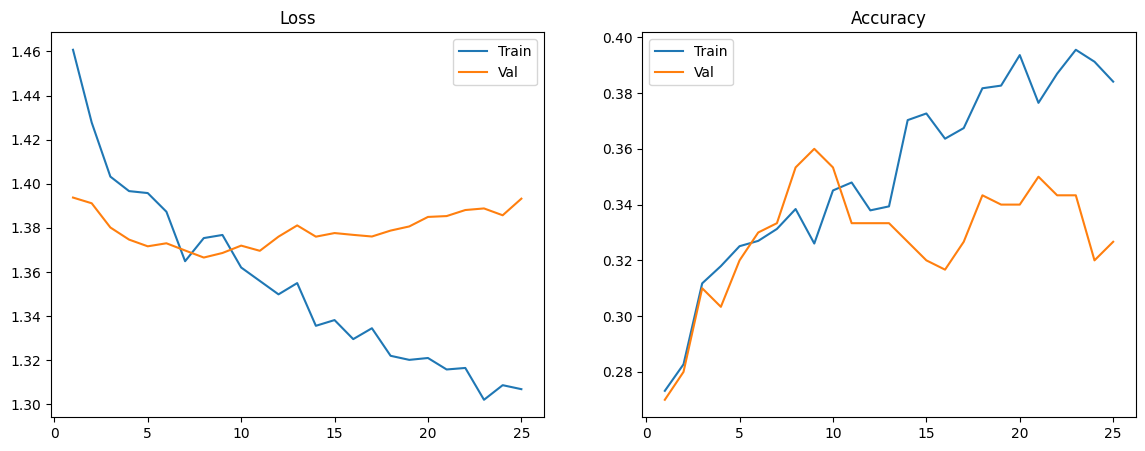

In [36]:
results = train_model(epochs=25)
plot_performance(results)

In [39]:
# --- ADD THIS FOR INFERENCE ---

class GeometryTestDataset(Dataset):
    def __init__(self, root_dir, tokenizer, transform=None, max_len=64):
        self.root_dir = root_dir
        self.folder_ids = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.transform = transform

    def __len__(self):
        return len(self.folder_ids)

    def __getitem__(self, idx):
        folder_id = self.folder_ids[idx]
        folder_path = os.path.join(self.root_dir, folder_id)

        with open(os.path.join(folder_path, "data.json"), 'r') as f:
            item = json.load(f)

        image = Image.open(os.path.join(folder_path, "img_diagram.png")).convert('RGB')
        if self.transform:
            image = self.transform(image)

        inputs = self.tokenizer(item['problem_text'], add_special_tokens=True, max_length=self.max_len,
                                padding='max_length', truncation=True, return_tensors='pt')

        return {
            'image': image,
            'input_ids': inputs['input_ids'].flatten(),
            'problem_id': folder_id
        }

def generate_predictions(test_dir="./test", model_path="best_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    test_tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_ds = GeometryTestDataset(test_dir, tokenizer, test_tf)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    # Re-initialize the model architecture and load weights
    model = BottleneckGeometrySolver(tokenizer.vocab_size).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    results = []
    idx_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}

    print(f"Generating predictions for {len(test_ds)} problems...")

    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(device)
            ids = batch['input_ids'].to(device)
            prob_id = batch['problem_id'][0]

            outputs = model(imgs, ids)
            pred_idx = outputs.argmax(1).item()

            results.append({
                "problem_id": prob_id,
                "prediction": idx_to_letter[pred_idx]
            })

    # Save final results to JSON
    with open("prediction.json", "w") as f:
        json.dump(results, f, indent=4)

    print("Results successfully saved to 'prediction.json'.")


In [40]:
generate_predictions()

Generating predictions for 601 problems...
Results successfully saved to 'prediction.json'.
